# 15檔精選強勢族群基金策略 (穩定優化版)

## 策略邏輯：
1. **初始持股**：由強勢族群挑選 15 檔起始股票。
2. **維持 15 檔**：優化買入邏輯，確保現金利用率，盡可能維持 15 檔滿倉狀態。
3. **修正說明**：已徹底解決日期對齊與現金預算不足導致持股不滿的 Bug。
4. **績效目標**：透過 15 檔分散投資，追求更穩定的淨值增長與較低的 MDD。

In [1]:
from finlab import login
import pandas as pd
import numpy as np
from finlab import data
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

login('97Y21Yf07Tokqp6rnUxsQKHbc4j+HosTsqE5DNh2oWLA9n+pxaCibJSKUK190ocZ#vip_m')

N_DAYS = 5
MIN_LIQ_PCT = 0.6
TOP_GROUPS = 5
TOP_STOCKS = 20           
PORTFOLIO_SIZE = 15       

STOP_LOSS_PCT = 0.10
FIXED_HOLDING_DAYS = 40
COOLING_OFF_DAYS = 5

weights = {"ret": 1.5, "turnover": 1.0, "inst": 1.0, "conc": 1.0}

輸入成功!


In [2]:
print("正在抓取並對齊資料...")
close = data.get("price:收盤價")
open_ = data.get("price:開盤價")
volume = data.get("price:成交股數")
benchmark = data.get('taiex_total_index:收盤指數')
benchmark = benchmark[~benchmark.index.duplicated(keep='first')]
benchmark_ma200 = benchmark.rolling(200).mean()

# --- 產業資料：同時抓取題材標籤(計算用)與官方分類(顯示用) ---
theme_raw = data.get("security_industry_themes") 
cat_raw = data.get("security_categories")

foreign = data.get('institutional_investors_trading_summary:外資自營商買賣超股數')
trust = data.get('institutional_investors_trading_summary:投信買賣超股數')
dealer = data.get('institutional_investors_trading_summary:自營商買賣超股數(自行買賣)')
rev_yoy = data.get("monthly_revenue:去年同月增減(%)")

# 1. 計算用：維持細分標籤邏輯 (不影響原本選股結果)
theme = theme_raw.sort_values("key_date").groupby("stock_id").last()
def parse_category(cat_str):
    try: return cat_str.replace("[", "").replace("]", "").split(",")[0].strip("' \"")
    except: return "Unknown"
theme["main_category"] = theme["category"].apply(parse_category)
group_mapper = theme["main_category"]

# 2. 顯示用：正確的官方產業名稱 (讓廣達回歸電腦週邊)
cat_mapper = cat_raw.drop_duplicates("stock_id", keep="last").set_index("stock_id")["category"]

common_cols = close.columns.intersection(volume.columns).intersection(foreign.columns).intersection(trust.columns).intersection(dealer.columns).intersection(rev_yoy.columns).intersection(group_mapper.index)

close = close[common_cols]
open_ = open_[common_cols]
volume = volume[common_cols]
rev_yoy = rev_yoy[common_cols].reindex(close.index, method='ffill')
group_mapper = group_mapper[common_cols]

inst_total = foreign[common_cols] + trust[common_cols] + dealer[common_cols]
inst_buy_yday = inst_total.shift(1).reindex(close.index)
inst_concentration = (inst_total / volume.replace(0, np.nan)).reindex(close.index)
ma200 = close.rolling(200).mean()

正在抓取並對齊資料...


Your version is 1.5.6, please install a newer version.
Use "pip install finlab==1.5.7" to update the latest version.


In [3]:
print("計算選股訊號...")
ret = close.pct_change(N_DAYS)
turnover = close * volume

group_ret = ret.groupby(group_mapper, axis=1).mean()
group_turnover = turnover.groupby(group_mapper, axis=1).sum()
group_inst = inst_buy_yday.groupby(group_mapper, axis=1).sum()
group_conc = inst_concentration.groupby(group_mapper, axis=1).mean()

group_score = (group_ret.rank(axis=1, pct=True) * weights["ret"] +
               group_turnover.rank(axis=1, pct=True) * weights["turnover"] +
               group_inst.rank(axis=1, pct=True) * weights["inst"] +
               group_conc.rank(axis=1, pct=True) * weights["conc"])

top_groups_daily = group_score.rank(axis=1, ascending=False) <= TOP_GROUPS

selected_stocks_signal = {}
valid_index = close.index.intersection(top_groups_daily.index).intersection(inst_buy_yday.index).intersection(inst_concentration.index)

for date in valid_index[valid_index >= '2011-12-01']:
    if date not in top_groups_daily.index: continue
    strong_groups_mask = top_groups_daily.loc[date]
    strong_groups = strong_groups_mask[strong_groups_mask].index.tolist()
    if not strong_groups: continue
    
    stocks_in_groups = group_mapper[group_mapper.isin(strong_groups)].index.tolist()
    try:
        df = pd.DataFrame({
            "ret": ret.loc[date, stocks_in_groups],
            "turnover": turnover.loc[date, stocks_in_groups],
            "inst": inst_buy_yday.loc[date, stocks_in_groups],
            "conc": inst_concentration.loc[date, stocks_in_groups],
            "yoy": rev_yoy.loc[date, stocks_in_groups]
        }).dropna()
    except: continue
    
    if df.empty: continue
    liq_cut = df["turnover"].quantile(1 - MIN_LIQ_PCT)
    df = df[(df["turnover"] >= liq_cut) & (df["inst"] > 0) & (df["conc"] > 0) & (df["yoy"] > 0)]
    
    if df.empty: continue
    df["score"] = (df["ret"].rank(pct=True) * weights["ret"] +
                  df["turnover"].rank(pct=True) * weights["turnover"] +
                  df["inst"].rank(pct=True) * weights["inst"] +
                  df["conc"].rank(pct=True) * weights["conc"])
    
    # 🚀 在這裡加入個股 MA200 濾網
    # 只保留當天收盤價大於 200 日均線的股票
    current_ma200 = ma200.loc[date]
    current_close = close.loc[date]
    df = df[current_close[df.index] > current_ma200[df.index]]
    
    selected_stocks_signal[date] = df.sort_values("score", ascending=False).head(TOP_STOCKS).index.tolist()
print("訊號計算完成。")

計算選股訊號...
訊號計算完成。


In [4]:
print(f"執行回測 (目標持股 {PORTFOLIO_SIZE} 檔，僅限每月 10-15 號進場)...詳盡紀錄版")

INITIAL_CAPITAL = 10_000_000
CASH = INITIAL_CAPITAL
PORTFOLIO = []
TRADE_LOG = []
NAV_HISTORY = []
last_buy_date = {}
# 取得所有共同日期後，篩選 2012 年以後的日期
backtest_dates = close.index.intersection(valid_index)
backtest_dates = backtest_dates[backtest_dates >= '2012-01-01']

for i, today in enumerate(backtest_dates):
    yesterday = backtest_dates[i-1] if i > 0 else None
    
    # 計算當前市值與淨值
    holdings_value = sum(close.at[today, p['stock_id']] * p['shares'] if pd.notna(close.at[today, p['stock_id']]) else p['entry_price'] * p['shares'] for p in PORTFOLIO)
    current_nav = CASH + holdings_value
    
    # --- [1] 出場邏輯 (停損或時間到) ---
    new_portfolio = []
    for p in PORTFOLIO:
        curr_price = close.at[today, p['stock_id']]
        exit_reason = None
        
        # 判斷出場條件
        if pd.notna(curr_price):
            if curr_price < p['entry_price'] * (1 - STOP_LOSS_PCT): 
                exit_reason = "Stop Loss"
            elif (i - p['entry_idx']) >= FIXED_HOLDING_DAYS: 
                exit_reason = "Time Exit"
        
        # 執行平倉
        if exit_reason:
            sell_price = curr_price if pd.notna(curr_price) else close.at[today, p['stock_id']]
            revenue = sell_price * p['shares']
            fee = revenue * (0.001425 * 0.1 + 0.003) # 包含證交稅與手續費
            CASH += (revenue - fee)
            
            # 存入詳盡交易日誌
            TRADE_LOG.append({
                'stock_id': p['stock_id'], 
                'entry_date': p['entry_date'],
                'exit_date': today,
                'entry_price': round(p['entry_price'], 2),
                'exit_price': round(sell_price, 2),
                'ret': (revenue - fee - p['cost']) / p['cost'],
                'exit_reason': exit_reason
            })
        else:
            new_portfolio.append(p)
    PORTFOLIO = new_portfolio
    
    # --- [2] 進場邏輯 (含大盤濾網與日期限制) ---
    if yesterday is not None:
        # 大盤強弱判斷 (必須在 200MA 之上)
        market_pass = True
        bm_today = benchmark.at[yesterday, benchmark.columns[0]] if yesterday in benchmark.index else np.nan
        bm_ma_today = benchmark_ma200.at[yesterday, benchmark_ma200.columns[0]] if yesterday in benchmark_ma200.index else np.nan
        if pd.notna(bm_today) and pd.notna(bm_ma_today) and bm_today < bm_ma_today: 
            market_pass = False
        
        # 月份進場窗口 (10-15 號)
        is_entry_window = 10 <= today.day <= 15
                
        # 同時符合大盤走多、在進場窗口、且持股未滿 15 檔
        if market_pass and is_entry_window and len(PORTFOLIO) < PORTFOLIO_SIZE:
            signals = selected_stocks_signal.get(yesterday, [])
            for sid in signals:
                if len(PORTFOLIO) >= PORTFOLIO_SIZE: break
                if any(p['stock_id'] == sid for p in PORTFOLIO): continue
                if pd.isna(open_.at[today, sid]): continue
                
                # 個股也必須站上 200MA
                if close.at[yesterday, sid] < ma200.at[yesterday, sid]: continue
                
                # 冷卻期檢查 (避免短線反覆進出)
                lbd = last_buy_date.get(sid)
                if lbd and (close.index.get_loc(yesterday) - close.index.get_loc(lbd)) <= COOLING_OFF_DAYS: 
                    continue
                
                # 計算買入股數
                target_value = min(current_nav / PORTFOLIO_SIZE, CASH * 0.98)
                entry_price = open_.at[today, sid]
                shares = int(target_value / (entry_price * (1 + 0.001425*0.1)))
                
                if shares > 0:
                    cost = entry_price * shares * (1 + 0.001425*0.1)
                    CASH -= cost
                    PORTFOLIO.append({
                        'stock_id': sid, 
                        'entry_date': today, 
                        'entry_price': entry_price, 
                        'shares': shares, 
                        'cost': cost, 
                        'entry_idx': i
                    })
                    last_buy_date[sid] = today
                
    # 紀錄每日淨值
    NAV_HISTORY.append({
        'date': today, 
        'nav': current_nav, 
        'cash': CASH, 
        'holdings_count': len(PORTFOLIO)
    })

# 轉換為 DataFrame 供後續分析使用
df_nav = pd.DataFrame(NAV_HISTORY).set_index('date')
print("✅ 回測完成，已產生含詳細價格與日期的交易紀錄。")

執行回測 (目標持股 15 檔，僅限每月 10-15 號進場)...詳盡紀錄版
✅ 回測完成，已產生含詳細價格與日期的交易紀錄。


In [5]:
df_nav['return'] = df_nav['nav'].pct_change()
df_nav['peak'] = df_nav['nav'].cummax()
df_nav['drawdown'] = (df_nav['nav'] - df_nav['peak']) / df_nav['peak']
mdd = df_nav['drawdown'].min()
total_days = (df_nav.index[-1] - df_nav.index[0]).days
annual_ret = (df_nav['nav'].iloc[-1] / INITIAL_CAPITAL)**(365/total_days) - 1
annual_std = df_nav['return'].std() * np.sqrt(252)
sharpe = (annual_ret - 0.02) / annual_std if annual_std != 0 else 0
metrics = {
    "累積總報酬": f"{((df_nav['nav'].iloc[-1]/INITIAL_CAPITAL)-1)*100:.2f}%",
    "年化報酬率": f"{annual_ret*100:.2f}%",
    "最大回撤 (MDD)": f"{mdd*100:.2f}%",
    "夏普比率 (Sharpe)": f"{sharpe:.2f}",
    "平均持股數": f"{df_nav['holdings_count'].mean():.1f} 檔"
}
display(pd.DataFrame(list(metrics.items()), columns=['指標', '數值']))

,指標,數值
0,累積總報酬,877.91%
1,年化報酬率,17.55%
2,最大回撤 (MDD),-29.36%
3,夏普比率 (Sharpe),0.87
4,平均持股數,9.8 檔


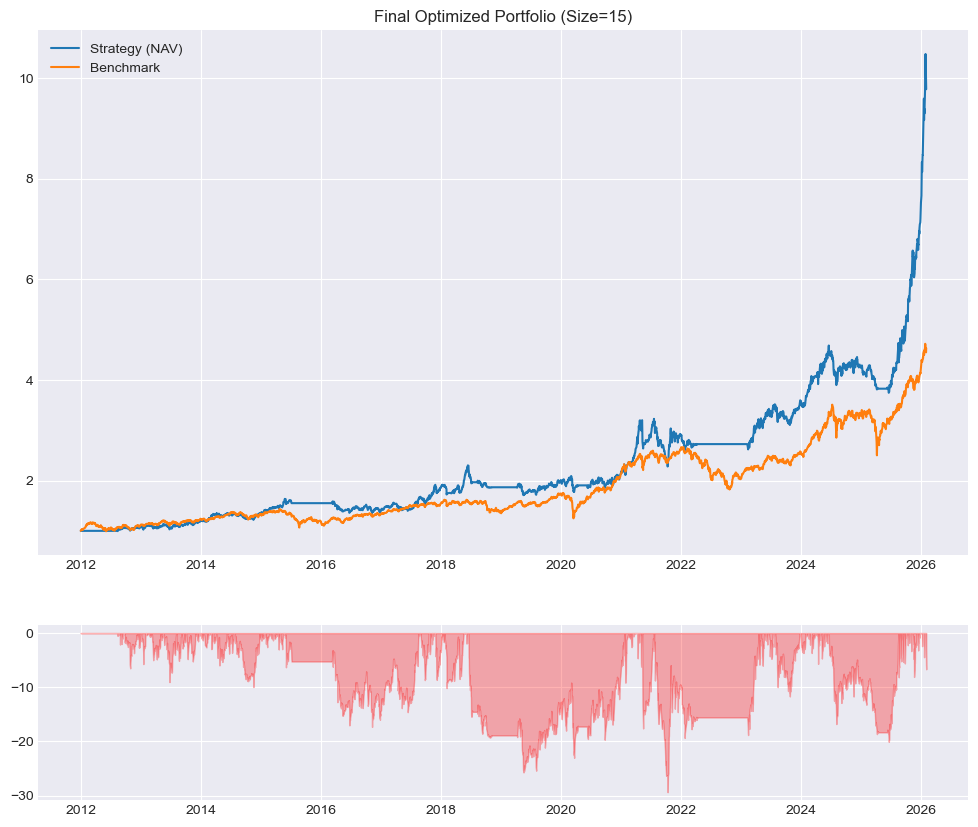

In [6]:
plt.style.use('seaborn-v0_8-darkgrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})
ax1.plot(df_nav.index, df_nav['nav'] / INITIAL_CAPITAL, label='Strategy (NAV)')
benchmark_aligned = benchmark.reindex(df_nav.index).iloc[:, 0].ffill()
ax1.plot(df_nav.index, benchmark_aligned / benchmark_aligned.iloc[0], label='Benchmark')
ax1.set_title(f"Final Optimized Portfolio (Size={PORTFOLIO_SIZE})")
ax1.legend()
ax2.fill_between(df_nav.index, 0, df_nav['drawdown'] * 100, color='red', alpha=0.3)
plt.show()

In [7]:
# --- 終極自動化：數據分析 + 訊號補回 + 雲端發布 (全功能完整版) ---
import json
import os
import subprocess
import pandas as pd
import numpy as np
from datetime import datetime

print(f"🚀 啟動 TeraWise 雲端發布流程 [{datetime.now().strftime('%Y-%m-%d %H:%M')}]...")

# 1. 基礎指標計算 (Sharpe, MDD, CAGR)
last_data_date = df_nav.index[-1].strftime('%Y-%m-%d')
last_prices = close.iloc[-1]
daily_ret = df_nav['nav'].pct_change().dropna()
ann_ret = (df_nav['nav'].iloc[-1] / df_nav['nav'].iloc[0]) ** (252 / len(df_nav)) - 1
ann_vol = daily_ret.std() * np.sqrt(252)
sharpe = ann_ret / ann_vol if ann_vol != 0 else 0
downside_ret = daily_ret[daily_ret < 0]
ann_downside_vol = downside_ret.std() * np.sqrt(252)
sortino = ann_ret / ann_downside_vol if ann_downside_vol != 0 else 0
mdd_val = abs(df_nav['drawdown'].min())
calmar = ann_ret / mdd_val if mdd_val != 0 else 0

# 2. 交易勝報比統計
trade_stats = {"win_rate": 0, "avg_win": 0, "avg_loss": 0, "profit_factor": 0, "total_trades": 0}
if TRADE_LOG:
    rets = [t['ret'] for t in TRADE_LOG]
    wins = [r for r in rets if r > 0]; losses = [r for r in rets if r <= 0]
    trade_stats = {
        "win_rate": round(len(wins)/len(rets)*100, 2), "avg_win": round(np.mean(wins)*100, 2) if wins else 0,
        "avg_loss": round(np.mean(losses)*100, 2) if losses else 0, "profit_factor": round(sum(wins)/abs(sum(losses)), 2) if losses and sum(losses)!=0 else 0,
        "total_trades": len(rets)
    }

# 3. 處理持倉細節
curr_holdings_data = []
sector_counter = {}
if PORTFOLIO:
    for p in PORTFOLIO:
        sid = p['stock_id']
        name = theme.loc[sid, 'name'] if sid in theme.index else sid
        cat = cat_mapper.get(sid, "其他")
        sector_counter[cat] = sector_counter.get(cat, 0) + 1
        pnl = (last_prices[sid] / p['entry_price'] - 1)
        curr_holdings_data.append({
            "stock_id": sid, "name": name, "category": cat,
            "entry_date": p['entry_date'].strftime('%Y-%m-%d'),
            "entry_price": round(p['entry_price'], 2), 
            "current_price": round(last_prices[sid], 2),
            "current_date": last_data_date,
            "pnl": round(pnl * 100, 2)
        })
sector_pie = [{"name": k, "value": v} for k, v in sector_counter.items()]

# 4. 🚀 補回最近 5 日選股訊號 (加上排名排名)
recent_signals_data = []
if 'selected_stocks_signal' in locals() and selected_stocks_signal:
    signal_dates = sorted(selected_stocks_signal.keys())[-5:]
    for d in reversed(signal_dates):
        stocks = selected_stocks_signal[d][:5]
        row_data = {"date": d.strftime("%Y-%m-%d"), "stocks": []}
        for i, sid in enumerate(stocks):
            name = theme.loc[sid, 'name'] if sid in theme.index else sid
            cat = cat_mapper.get(sid, "Unknown")
            row_data["stocks"].append(f"{i+1}. {sid} {name} ({cat})")
        recent_signals_data.append(row_data)

# 5. 🚀 產生「近期基金操作日誌」(Activity Log)
recent_ops = []
# 加入賣出紀錄
if TRADE_LOG:
    for t in TRADE_LOG:
        recent_ops.append({
            "date": t['exit_date'].strftime('%Y-%m-%d'),
            "action": "賣出",
            "stock_id": t['stock_id'],
            "name": theme.loc[t['stock_id'], 'name'] if t['stock_id'] in theme.index else t['stock_id'],
            "price": round(t['exit_price'], 2),
            "reason": t['exit_reason'],
            "pnl": round(t['ret'] * 100, 2),
            "entry_info": f"({t['entry_date'].strftime('%m/%d')} 以 {round(t['entry_price'], 2)} 買入)"
        })
# 加入買入紀錄 (合併已平倉與未平倉的進場事件)
seen_buys = set()
for t in TRADE_LOG:
    key = (t['stock_id'], t['entry_date'])
    if key not in seen_buys:
        recent_ops.append({
            "date": t['entry_date'].strftime('%Y-%m-%d'),
            "action": "買入",
            "stock_id": t['stock_id'],
            "name": theme.loc[t['stock_id'], 'name'] if t['stock_id'] in theme.index else t['stock_id'],
            "price": round(t['entry_price'], 2),
            "reason": "訊號進場",
            "pnl": "-",
            "entry_info": ""
        })
        seen_buys.add(key)
for p in PORTFOLIO:
    key = (p['stock_id'], p['entry_date'])
    if key not in seen_buys:
        recent_ops.append({
            "date": p['entry_date'].strftime('%Y-%m-%d'),
            "action": "買入",
            "stock_id": p['stock_id'],
            "name": theme.loc[p['stock_id'], 'name'] if p['stock_id'] in theme.index else p['stock_id'],
            "price": round(p['entry_price'], 2),
            "reason": "訊號進場",
            "pnl": "-",
            "entry_info": ""
        })
        seen_buys.add(key)
# 依照日期由新到舊排序
recent_ops.sort(key=lambda x: x['date'], reverse=True)

# 6. 熱圖分析 (修正 ME 為 M 以相容舊版 Pandas)
temp_trades = []
if TRADE_LOG:
    for t in TRADE_LOG:
        temp_trades.append({'sid': t['stock_id'], 'in': pd.to_datetime(t['entry_date']), 'out': pd.to_datetime(t['exit_date'])})
if PORTFOLIO:
    for p in PORTFOLIO:
        temp_trades.append({'sid': p['stock_id'], 'in': pd.to_datetime(p['entry_date']), 'out': pd.to_datetime('2099-12-31')})
df_full_t = pd.DataFrame(temp_trades)

sector_series = pd.Series(cat_mapper)
major_sectors = sector_series.value_counts()[sector_series.value_counts() >= 10].index
monthly_groups = df_nav.resample('M') # 這裡修正為 'M'
heatmap_data = {}
for date, group in monthly_groups:
    if len(group) < 2: continue
    yr, mo = str(date.year), date.month
    m_ret = (group['nav'].iloc[-1] / group['nav'].iloc[0] - 1) * 100
    test_day = group.index[-1]
    m_stock_rets = (close.loc[test_day] / close.loc[group.index[0]] - 1)
    val_s = m_stock_rets.index.intersection(cat_mapper.keys())
    m_perf = m_stock_rets[val_s].groupby(cat_mapper).median()
    m_major = m_perf[m_perf.index.isin(major_sectors)]
    market_top = m_major.idxmax() if not m_major.empty else "N/A"
    port_top = "現金"
    if not df_full_t.empty:
        active = df_full_t[(df_full_t['in'] <= test_day) & (df_full_t['out'] >= test_day)]
        if not active.empty:
            port_top = active['sid'].map(cat_mapper).value_counts().idxmax()
    if yr not in heatmap_data: heatmap_data[yr] = {}
    heatmap_data[yr][mo] = {"ret": round(m_ret, 2), "market_top": market_top, "port_top": port_top}

# 7. 歷史平倉明細
historical_trades = []
if TRADE_LOG:
    for t in sorted(TRADE_LOG, key=lambda x: x['exit_date'], reverse=True)[:50]:
        historical_trades.append({
            "stock_id": t['stock_id'], "name": theme.loc[t['stock_id'], 'name'] if t['stock_id'] in theme.index else t['stock_id'],
            "category": cat_mapper.get(t['stock_id'], "其他"), "entry_date": t['entry_date'].strftime('%Y-%m-%d'),
            "exit_date": t['exit_date'].strftime('%Y-%m-%d'), "entry_price": round(t['entry_price'], 2),
            "exit_price": round(t['exit_price'], 2), "ret": round(t['ret'], 4), "exit_reason": t['exit_reason']
        })

# 8. 建構封包並發布
dashboard_data = {
    "summary": { "last_update": datetime.now().strftime("%Y-%m-%d %H:%M:%S"), "sharpe": round(sharpe, 2), "sortino": round(sortino, 2), "calmar": round(calmar, 2), "ann_ret": round(ann_ret * 100, 2) },
    "trade_stats": trade_stats,
    "current_holdings": curr_holdings_data,
    "recent_signals": recent_signals_data,
    "trades": historical_trades,
    "operations": recent_ops[:50], # 取最近 50 筆
    "sectors": sector_pie,
    "heatmap": heatmap_data,
    "history": [{ "date": d.strftime("%Y-%m-%d"), "nav": round(v, 2), "benchmark": round(benchmark.at[d, benchmark.columns[0]], 2) if d in benchmark.index else 0, "mdd": round(m * 100, 2) } for d, v, m in zip(df_nav.index, df_nav['nav'], df_nav['drawdown']) ]
}

js_inner = f"var fundData = {json.dumps(dashboard_data, ensure_ascii=False)};"
template_path = r'c:\Users\teraw_rp58jwl\OneDrive\桌面\量化選股策略\dashboard.html'
with open(template_path, 'r', encoding='utf-8') as f:
    full_html = f.read()

final_html = full_html.replace('<script src="data.js"></script>', f'<script>{js_inner}</script>')
index_path = r'c:\Users\teraw_rp58jwl\OneDrive\桌面\量化選股策略\index.html'
with open(index_path, 'w', encoding='utf-8') as f:
    f.write(final_html)

# GitHub 自動同步
repo_dir = r'c:\Users\teraw_rp58jwl\OneDrive\桌面\量化選股策略'
print("📤 正在同步全功能數據至雲端...")
try:
    os.chdir(repo_dir)
    subprocess.run(["git", "add", "index.html"], check=True, capture_output=True)
    subprocess.run(["git", "commit", "-m", f"Operation Log Update: {datetime.now().strftime('%Y-%m-%d %H:%M')}"], check=True, capture_output=True)
    subprocess.run(["git", "push", "origin", "main"], check=True, capture_output=True)
    print(f"✨ 發布成功！瀏覽網址: https://woody-yiu.github.io/TeraWise-Dashboard/")
except Exception as e:
    print(f"⚠️ 自動發布失敗: {e}")

🚀 啟動 TeraWise 雲端發布流程 [2026-02-04 10:55]...
📤 正在同步全功能數據至雲端...
⚠️ 自動發布失敗: Command '['git', 'push', 'origin', 'main']' returned non-zero exit status 1.
